# Notebook 02 — DINOv2 Workflow State (Approach B)

Workflow-state estimation from frozen **DINOv2 ViT-S/14** RGB embeddings.

Pipeline: extract 384-dim CLS embeddings (cached) -> window per recording ->
compare RF / LR / MLP -> select **MLP** -> probability smoothing (W=15, thr=0.6) ->
sustained commitment (K=3) -> crop ablation (full / center / gaze / hand).


## Setup

In [9]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

import constants as C
import dinov2_features as dino, postprocessing as pp
import metric_utils as mu, plot_utils as pl

OUT = C.DINOV2_OUT_DIR
OUT.mkdir(parents=True, exist_ok=True)

## Extract / load DINOv2 embeddings

In [10]:
# Extract frozen DINOv2 ViT-S/14 CLS embeddings (384-dim) for every 5th frame.
# This is the only step that needs torch + timm + a GPU; it caches to .npz, so on
# re-run (and in this repo, where the cache ships) it loads instantly without torch.
cache = dino.load_embeddings("full_frame")
if cache is None:
    cache = dino.extract_embeddings("full_frame")   # needs torch/timm/Pillow
print("embeddings:", cache["X_embeddings"].shape)

embeddings: (2346, 384)


## Window, split and standardise

In [11]:
def prepare(cache):
    """Window per recording, split train/test, standardise on train."""
    X = dino.rolling_mean_per_recording(cache["X_embeddings"], cache["recording_names"])
    Y, split = cache["Y_labels"], cache["split_names"]
    tr, te = split == "train", split == "test"
    sc = StandardScaler().fit(X[tr])
    meta = {"frame_names": cache["frame_names"][te],
            "recording_names": cache["recording_names"][te]}
    return sc.transform(X[tr]), Y[tr], sc.transform(X[te]), Y[te], meta

def get_models():
    return {
        "RF": MultiOutputClassifier(RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            random_state=C.RANDOM_STATE, n_jobs=-1)),
        "LR": MultiOutputClassifier(LogisticRegression(
            class_weight="balanced", max_iter=2000, solver="liblinear")),
        "MLP": MultiOutputClassifier(MLPClassifier(
            hidden_layer_sizes=(128,), alpha=1e-3, max_iter=500,
            early_stopping=True, random_state=C.RANDOM_STATE)),
    }

def proba_matrix(model, X):
    return np.column_stack([p[:, 1] for p in model.predict_proba(X)])

Xtr, Ytr, Xte, Yte, meta = prepare(cache)

## B1 — classifier comparison (RF / LR / MLP)

In [12]:
# B1 — compare RF / LR / MLP on the windowed embeddings (raw, threshold 0.5).
comparison, proba = [], {}
for name, model in get_models().items():
    model.fit(Xtr, Ytr)
    P = proba_matrix(model, Xte)
    proba[name] = P
    comparison.append({"model": name, **mu.evaluate(Yte, (P >= 0.5).astype(int))})

pd.DataFrame(comparison).to_csv(OUT / "classifier_comparison.csv", index=False)
pd.DataFrame(comparison)

,model,macro_f1,micro_f1,hamming_loss,exact_match,progress_mae,pred_transitions,mono_violations
0,RF,0.602873,0.848800,0.162178,0.298025,0.151805,29,23
1,LR,0.603515,0.752384,0.310792,0.141831,0.287652,132,114
2,MLP,0.703939,0.851209,0.165769,0.452424,0.151406,81,69


## B2 / B3 — probability smoothing and sustained commitment

MLP raw -> smoothing -> sustained K=3 (the selected final prototype).

In [13]:
# MLP is the selected model (best macro F1 and late-step F1 in B1).
# Final prototype: probability smoothing (W=15, threshold 0.6) + sustained commitment K=3.
P_mlp    = proba["MLP"]
P_smooth = pp.probability_smoothing(P_mlp, C.B_PROB_WINDOW)
y_raw    = (P_mlp >= 0.5).astype(int)
y_smooth = (P_smooth >= C.B_THRESHOLD).astype(int)
y_k3     = pp.sustained_commitment(P_smooth, C.B_THRESHOLD, C.B_SUSTAIN_K)

mlp_preds = {"mlp_raw": (y_raw, P_mlp),
             "mlp_smooth": (y_smooth, P_smooth),
             "mlp_k3": (y_k3, P_smooth)}

def save_preds(name, y_pred, P):
    df = pd.DataFrame({"recording": meta["recording_names"], "frame": meta["frame_names"]})
    for i, s in enumerate(C.EXPECTED_STEPS):
        df[f"true_step_{s}"] = Yte[:, i]
    for i, s in enumerate(C.EXPECTED_STEPS):
        df[f"pred_step_{s}"] = y_pred[:, i]
    for i, s in enumerate(C.EXPECTED_STEPS):
        df[f"prob_step_{s}"] = P[:, i]
    df.to_csv(OUT / name, index=False)

save_preds("predictions_mlp_raw.csv",    y_raw,    P_mlp)
save_preds("predictions_mlp_smooth.csv", y_smooth, P_smooth)
save_preds("predictions_mlp_k3.csv",     y_k3,     P_smooth)

postproc, transitions, late = [], [], []
for cfg, (yp, _) in mlp_preds.items():
    postproc.append({"config": cfg, **mu.evaluate(Yte, yp)})
    transitions.append({"config": cfg, **mu.transition_metrics(Yte, yp)})
    for r in mu.per_step_f1(Yte, yp):
        if r["step"] in C.LATE_STEPS:
            late.append({"config": cfg, "step": r["step"], "f1": r["f1"]})

pd.DataFrame(postproc).to_csv(OUT / "postprocessing_results.csv", index=False)
pd.DataFrame(transitions).to_csv(OUT / "transition_metrics.csv", index=False)
pd.DataFrame(late).to_csv(OUT / "late_step_metrics.csv", index=False)
pd.DataFrame(postproc)

,config,macro_f1,micro_f1,hamming_loss,exact_match,progress_mae,pred_transitions,mono_violations
0,mlp_raw,0.703939,0.851209,0.165769,0.452424,0.151406,81,69
1,mlp_smooth,0.801090,0.872856,0.136046,0.477558,0.128067,31,21
2,mlp_k3,0.812801,0.895677,0.116497,0.639138,0.116497,4,0


## B5 — crop ablation

full_frame keeps the late-step signal (step 27); cropping onto hands removes early
over-commit but loses step 27. full_frame + smoothing is kept as the base.

In [14]:

ablation = []
for mode in C.CROP_MODES:
    cm = dino.load_embeddings(mode)
    if cm is None:
        cm = dino.extract_embeddings(mode)   # needs torch/timm/Pillow
    xtr, ytr, xte, yte, _ = prepare(cm)
    model = get_models()["MLP"].fit(xtr, ytr)
    P  = pp.probability_smoothing(proba_matrix(model, xte), C.B_PROB_WINDOW)
    yp = pp.sustained_commitment(P, C.B_THRESHOLD, C.B_SUSTAIN_K)
    m  = mu.evaluate(yte, yp)
    f1 = {r["step"]: r["f1"] for r in mu.per_step_f1(yte, yp)}
    ablation.append({"crop_mode": mode, "macro_f1": m["macro_f1"],
                     "hamming_loss": m["hamming_loss"], "mono_violations": m["mono_violations"],
                     "f1_step_27": f1[27], "f1_step_30": f1[30]})

pd.DataFrame(ablation).to_csv(OUT / "crop_ablation.csv", index=False)
pd.DataFrame(ablation)

,crop_mode,macro_f1,hamming_loss,mono_violations,f1_step_27,f1_step_30
0,full_frame,0.812801,0.116497,0,0.800000,0.995370
1,center_crop,0.612520,0.352284,0,0.071599,0.828244
2,gaze_crop,0.643637,0.255735,0,0.140845,0.995413
3,hand_crop,0.707226,0.088969,0,0.000000,0.979684


## Plots (loaded from the saved CSVs)

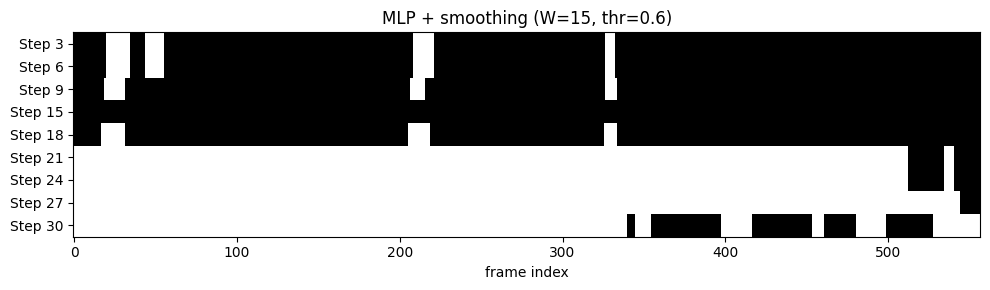

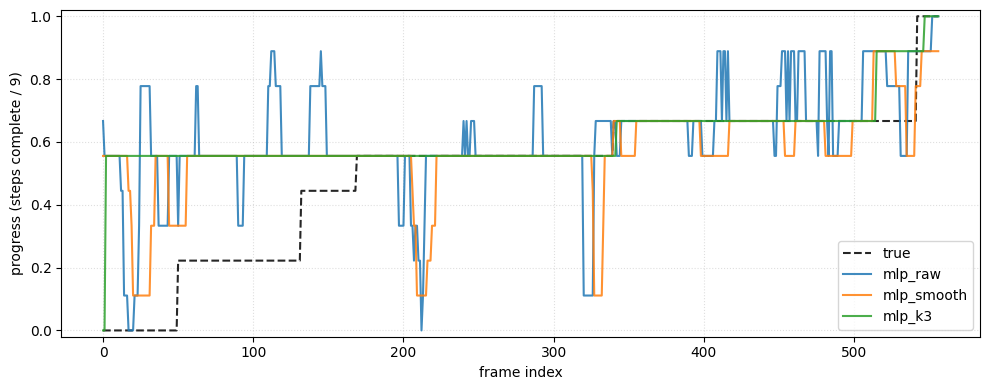

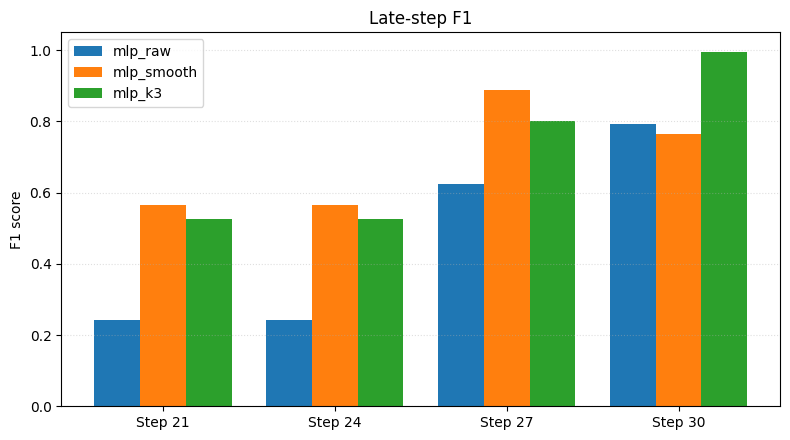

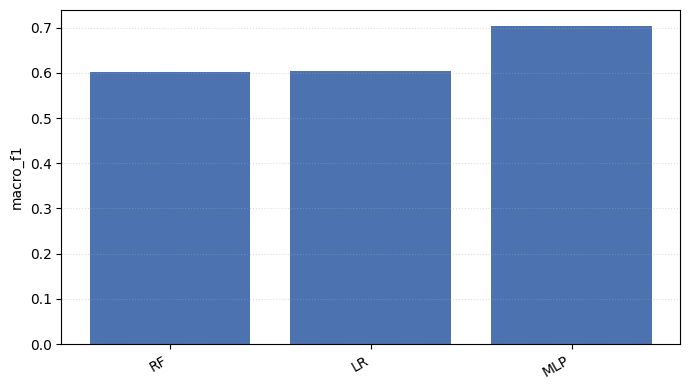

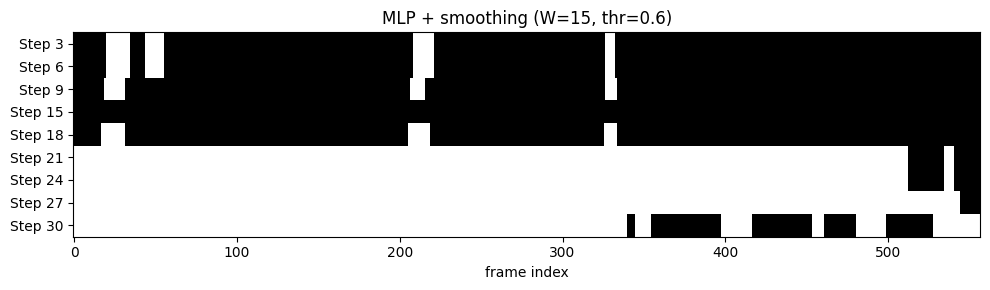

In [15]:
# Plots from the saved CSVs.
pd.DataFrame({"frame_idx": np.arange(len(Yte)),
              "true": Yte.sum(1) / C.N_STEPS,
              "mlp_raw": y_raw.sum(1) / C.N_STEPS,
              "mlp_smooth": y_smooth.sum(1) / C.N_STEPS,
              "mlp_k3": y_k3.sum(1) / C.N_STEPS}).to_csv(OUT / "progress_curve.csv", index=False)

pl.plot_progress_curve(pd.read_csv(OUT / "progress_curve.csv"), OUT / "progress_curve.png")
pl.plot_late_step_f1(pd.read_csv(OUT / "late_step_metrics.csv"), save_path=OUT / "late_step_f1.png")
pl.plot_metric_bars(pd.read_csv(OUT / "classifier_comparison.csv"), "macro_f1",
                    label_col="model", save_path=OUT / "classifier_comparison.png")
pl.plot_state_heatmap(y_smooth, "MLP + smoothing (W=15, thr=0.6)",
                      OUT / "state_heatmap_mlp_smooth.png")

late-step F1  | A3 sensor smooth   <- C:\Users\purus\Documents\Work\resume\PhD\Uppasala\Multimodal AI and XR for Human-Centric Manufacturing\3rd\AI_XR\submission\outputs\sensor\late_step_f1.csv  [config=A3_smooth]
late-step F1  | A5 sensor K=15     <- C:\Users\purus\Documents\Work\resume\PhD\Uppasala\Multimodal AI and XR for Human-Centric Manufacturing\3rd\AI_XR\submission\outputs\sensor\late_step_f1.csv  [config=A5_sustained]
late-step F1  | B1 DINOv2 MLP raw  <- C:\Users\purus\Documents\Work\resume\PhD\Uppasala\Multimodal AI and XR for Human-Centric Manufacturing\3rd\AI_XR\submission\outputs\dinov2\late_step_metrics.csv  [config=mlp_raw]
late-step F1  | B2 DINOv2 smooth   <- C:\Users\purus\Documents\Work\resume\PhD\Uppasala\Multimodal AI and XR for Human-Centric Manufacturing\3rd\AI_XR\submission\outputs\dinov2\late_step_metrics.csv  [config=mlp_smooth]
late-step F1  | Candidate K=3      <- C:\Users\purus\Documents\Work\resume\PhD\Uppasala\Multimodal AI and XR for Human-Centric Manuf

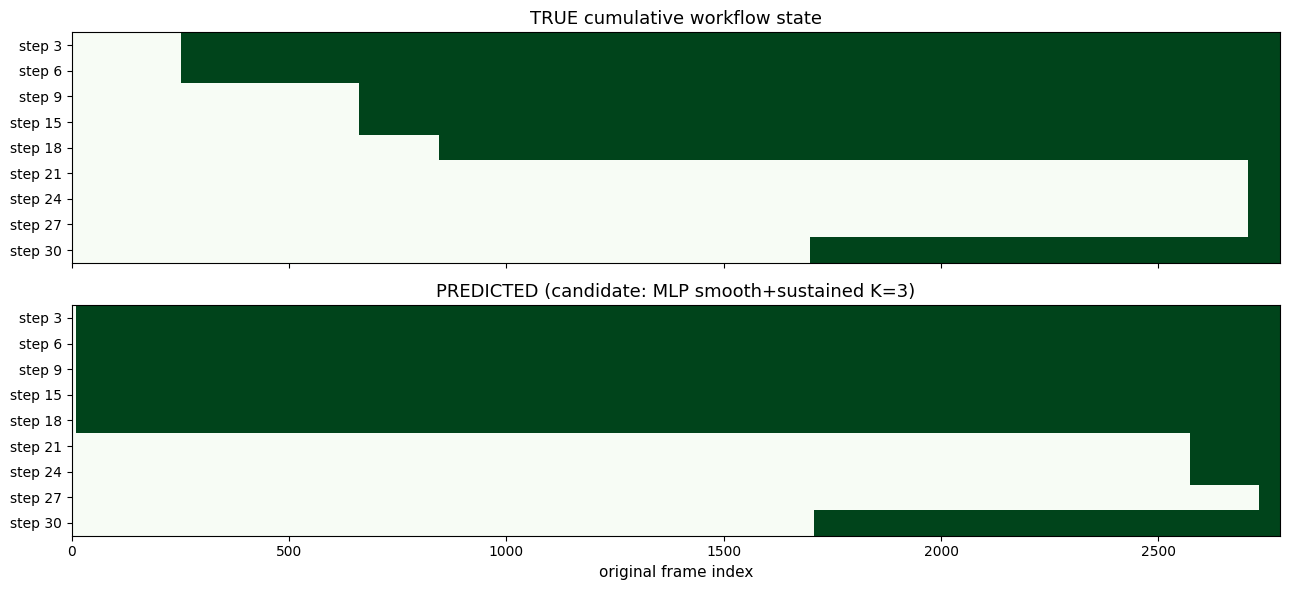

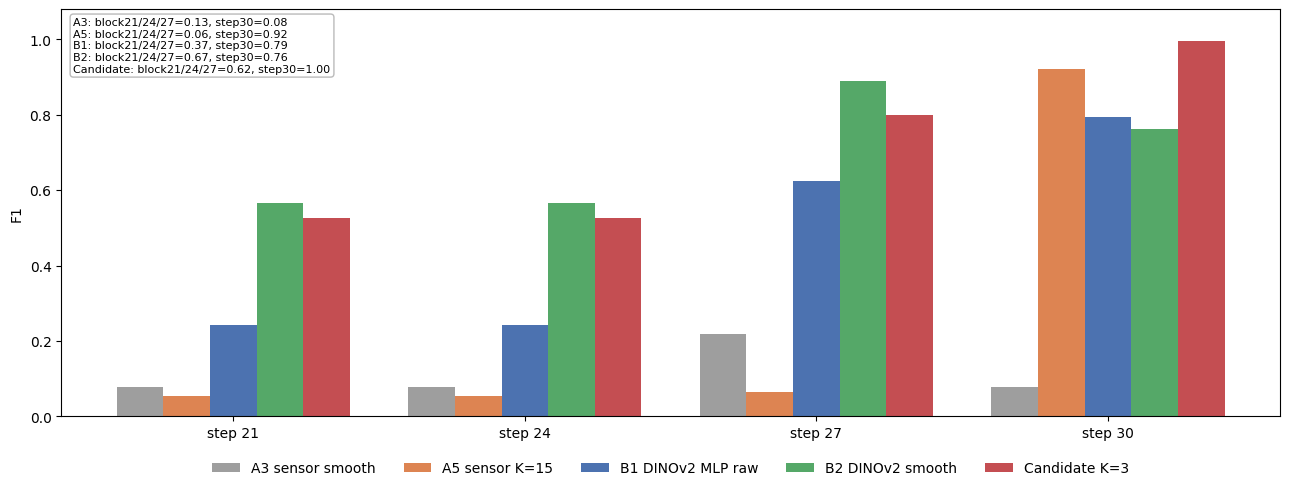

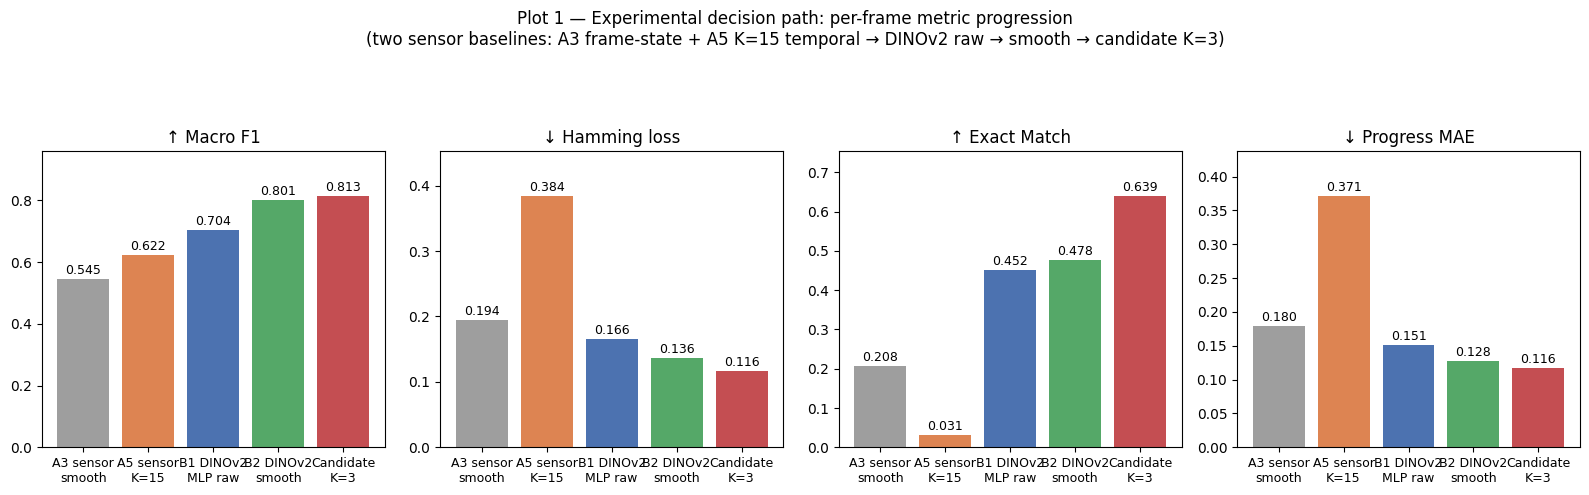

In [17]:
# Workflow-state summary plots — loaded from the saved result CSVs only.
import importlib
pl = importlib.reload(pl)   # pick up the new plot_utils helpers in a live kernel

PLOTS = C.OUTPUT_DIR / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)
SENSOR, DINO = C.SENSOR_OUT_DIR, C.DINOV2_OUT_DIR

# method label -> (source CSV, config name inside that CSV)
LATE_SOURCES = [
    ("A3 sensor smooth",  SENSOR / "late_step_f1.csv",      "A3_smooth"),
    ("A5 sensor K=15",    SENSOR / "late_step_f1.csv",      "A5_sustained"),
    ("B1 DINOv2 MLP raw", DINO   / "late_step_metrics.csv", "mlp_raw"),
    ("B2 DINOv2 smooth",  DINO   / "late_step_metrics.csv", "mlp_smooth"),
    ("Candidate K=3",     DINO   / "late_step_metrics.csv", "mlp_k3"),
]
METRIC_SOURCES = [
    ("A3 sensor smooth",  SENSOR / "summary_metrics.csv",        "A3_smooth"),
    ("A5 sensor K=15",    SENSOR / "summary_metrics.csv",        "A5_sustained"),
    ("B1 DINOv2 MLP raw", DINO   / "postprocessing_results.csv", "mlp_raw"),
    ("B2 DINOv2 smooth",  DINO   / "postprocessing_results.csv", "mlp_smooth"),
    ("Candidate K=3",     DINO   / "postprocessing_results.csv", "mlp_k3"),
]

# ---- combined late-step F1 table (method, step, f1) ----
late_rows = []
for method, path, cfg in LATE_SOURCES:
    print(f"late-step F1  | {method:18s} <- {path}  [config={cfg}]")
    src = pd.read_csv(path)
    sub = src[src["config"] == cfg]
    for _, r in sub.iterrows():
        late_rows.append({"method": method, "step": int(r["step"]), "f1": float(r["f1"])})
late_step_df = pd.DataFrame(late_rows)
late_step_df.to_csv(PLOTS / "late_step_f1_plot_data.csv", index=False)
print("\nlate_step_df:")
print(late_step_df)

# ---- combined metric-progression table ----
metric_cols = ["macro_f1", "hamming_loss", "exact_match", "progress_mae"]
metric_rows = []
for method, path, cfg in METRIC_SOURCES:
    print(f"\nmetrics       | {method:18s} <- {path}  [config={cfg}]")
    src = pd.read_csv(path)
    row = src[src["config"] == cfg].iloc[0]
    metric_rows.append({"method": method, **{c: float(row[c]) for c in metric_cols}})
metric_progression_df = pd.DataFrame(metric_rows)
metric_progression_df.to_csv(PLOTS / "metric_progression_plot_data.csv", index=False)
print("\nmetric_progression_df:")
print(metric_progression_df)

# ---- heatmap source: final candidate prediction CSV ----
cand_path = DINO / "predictions_mlp_k3.csv"
print(f"\nheatmap       | candidate predictions <- {cand_path}")
cand = pd.read_csv(cand_path)
frame_idx = cand["frame"].str.replace(".jpg", "", regex=False).astype(int).to_numpy()
Y_true = cand[[f"true_step_{s}" for s in C.EXPECTED_STEPS]].to_numpy()
Y_pred = cand[[f"pred_step_{s}" for s in C.EXPECTED_STEPS]].to_numpy()

# ---- draw and save ----
pl.plot_final_state_heatmap(frame_idx, Y_true, Y_pred,
                            save_path=PLOTS / "partA_final_heatmap.png")
pl.plot_late_step_f1_summary(pd.read_csv(PLOTS / "late_step_f1_plot_data.csv"),
                             save_path=PLOTS / "partA_late_step_f1.png")
pl.plot_metric_progression(pd.read_csv(PLOTS / "metric_progression_plot_data.csv"),
                           save_path=PLOTS / "partA_metric_progression.png")
print("\nsaved:", sorted(p.name for p in PLOTS.glob("partA_*.png")))